## Logistic Regression Project

This project demonstrates two types of logistic regression:
1.  **Binary Logistic Regression**: Predicting a binary outcome (e.g., whether a person buys insurance).
2.  **Multi-class Logistic Regression**: Classifying data into multiple categories (e.g., different species of iris flowers).

In [ ]:
# Common imports for the project
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# This magic command ensures plots are displayed inline in the notebook
%matplotlib inline

### Part 1: Binary Logistic Regression (Insurance Data)

This section uses a dataset to predict whether a person will buy insurance based on their age.

#### Data Loading (Binary Logistic Regression)

In [ ]:
# Load the insurance data
df_insurance = pd.read_csv("/content/insurance_data.csv")
print("First 5 rows of the insurance data:")
display(df_insurance.head())

First 5 rows of the insurance data:


,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


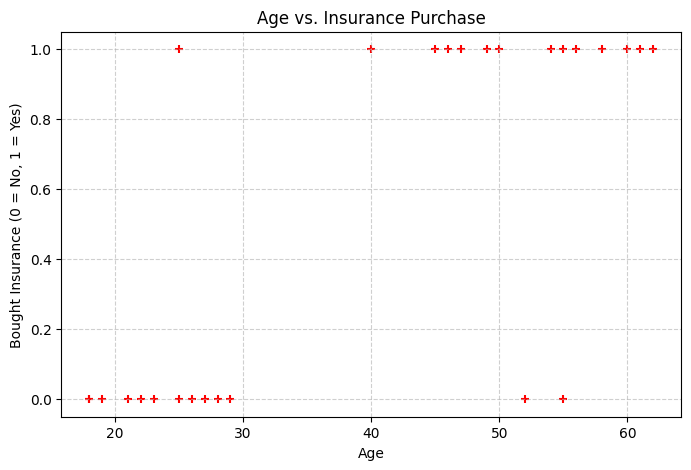

In [ ]:
# Visualize the relationship between age and buying insurance
plt.figure(figsize=(8, 5))
plt.scatter(df_insurance.age, df_insurance.bought_insurance, marker='+', color='red')
plt.title('Age vs. Insurance Purchase')
plt.xlabel('Age')
plt.ylabel('Bought Insurance (0 = No, 1 = Yes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Data Preprocessing (Binary Logistic Regression)

#### Data Splitting for Binary Logistic Regression

We split the data into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
X_insurance = df_insurance[['age']]
y_insurance = df_insurance.bought_insurance

X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(X_insurance, y_insurance, train_size=0.9, random_state=10)

print(f"Shape of X_train_insurance: {X_train_insurance.shape}")
print("X_test_insurance (first 5 rows):")
display(X_test_insurance.head())
print("y_test_insurance (first 5 rows):")
display(y_test_insurance.head())

Shape of X_train_insurance: (24, 1)
X_test_insurance (first 5 rows):


,age
7,60
5,56
18,19


y_test_insurance (first 5 rows):


,bought_insurance
7,1
5,1
18,0


#### Model Building and Training (Binary Logistic Regression)

#### Model Training and Prediction (Binary Logistic Regression)

We train a `LogisticRegression` model and make predictions.

In [ ]:
model_insurance = LogisticRegression()
model_insurance.fit(X_train_insurance, y_train_insurance)

y_predicted_insurance = model_insurance.predict(X_test_insurance)

print("Predicted values for X_test_insurance:")
print(y_predicted_insurance)

print(f"\nModel accuracy on test data: {model_insurance.score(X_test_insurance, y_test_insurance):.2f}")

Predicted values for X_test_insurance:
[1 1 0]

Model accuracy on test data: 1.00


#### Model Evaluation (Binary Logistic Regression)

#### Probability Prediction and Manual Sigmoid Calculation

The model can also predict probabilities. We can verify this with a manual sigmoid function calculation using the model's coefficients.

In [ ]:
print("Predicted probabilities for X_test_insurance (first 5 rows):")
print(model_insurance.predict_proba(X_test_insurance).round(2))

# Predict for a new age (e.g., 60)
age_to_predict = 60
y_predicted_single = model_insurance.predict(np.array([[age_to_predict]]))
print(f"\nPrediction for age {age_to_predict}: {y_predicted_single[0]} (0=No, 1=Yes)")

print(f"\nModel Coefficients (m in y=m*x+b): {model_insurance.coef_[0][0]:.3f}")
print(f"Model Intercept (b in y=m*x+b): {model_insurance.intercept_[0]:.3f}")

# Manual sigmoid function for verification
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

def prediction_function_manual(age):
   # Using the model's learned coefficients and intercept
   z = model_insurance.coef_[0][0] * age + model_insurance.intercept_[0]
   y = sigmoid(z)
   return y

# Example for age 35
example_age = 35
manual_prediction_prob = prediction_function_manual(example_age)
print(f"\nManual prediction probability for age {example_age}: {manual_prediction_prob:.2f}")
if manual_prediction_prob < 0.5:
    print(f"{manual_prediction_prob:.2f} is less than 0.5, which means a person with age {example_age} is predicted NOT to buy insurance.")
else:
    print(f"{manual_prediction_prob:.2f} is greater than or equal to 0.5, which means a person with age {example_age} is predicted to buy insurance.")

Predicted probabilities for X_test_insurance (first 5 rows):
[[0.06 0.94]
 [0.1  0.9 ]
 [0.93 0.07]]

Prediction for age 60: 1 (0=No, 1=Yes)

Model Coefficients (m in y=m*x+b): 0.127
Model Intercept (b in y=m*x+b): -4.973

Manual prediction probability for age 35: 0.37
0.37 is less than 0.5, which means a person with age 35 is predicted NOT to buy insurance.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


#### Confusion Matrix (Binary Logistic Regression)

Let's visualize the confusion matrix for the binary logistic regression model to understand its performance in more detail.

<Figure size 800x600 with 0 Axes>

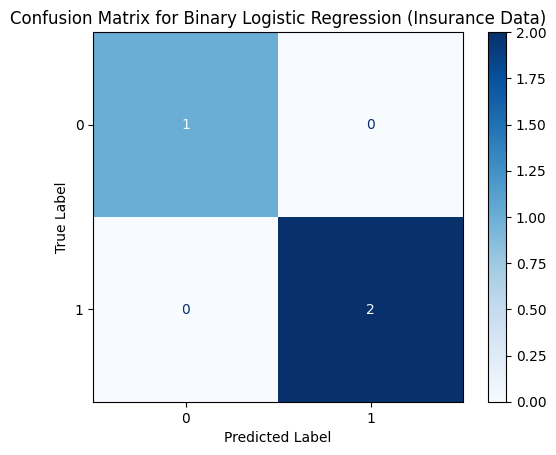

In [ ]:
cm_insurance = confusion_matrix(y_test_insurance, y_predicted_insurance)

# Display the confusion matrix
cm_display_insurance = ConfusionMatrixDisplay(confusion_matrix = cm_insurance, display_labels = model_insurance.classes_)

plt.figure(figsize=(8, 6))
cm_display_insurance.plot(cmap='Blues')
plt.title('Confusion Matrix for Binary Logistic Regression (Insurance Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Part 2: Multi-class Logistic Regression (Iris Dataset)

This section demonstrates logistic regression for classifying data into more than two categories using the Iris dataset.

#### Data Loading (Multi-class Logistic Regression)

In [ ]:
# Load the Iris dataset
# Using '/content/iris (1).csv' as it's available in the kernel files
iris_df = pd.read_csv("/content/iris (1).csv")
print("First 5 rows of the Iris dataset:")
display(iris_df.head())
print("\nUnique species in the dataset:")
print(iris_df['species'].unique())

First 5 rows of the Iris dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Unique species in the dataset:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


#### Data Preprocessing (Multi-class Logistic Regression)

In [ ]:
# Define features (X) and target (y)
X_iris = iris_df.drop('species', axis='columns') # Features (sepal length, sepal width, petal length, petal width)
y_iris = iris_df.species # Target labels (Setosa, Versicolor, Virginica)

# Split the dataset into 80% training and 20% testing
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

print(f"Shape of X_train_iris: {X_train_iris.shape}")
print(f"Shape of X_test_iris: {X_test_iris.shape}")

Shape of X_train_iris: (120, 4)
Shape of X_test_iris: (30, 4)


#### Model Building and Training (Multi-class Logistic Regression)

#### Model Training and Prediction (Multi-class Logistic Regression)

We initialize a Logistic Regression model with `multi_class='multinomial'` for multi-class classification and train it on the Iris dataset.

In [ ]:
# Initialize the Multinomial Logistic Regression model
# Use 'multinomial' for multi-class classification and 'lbfgs' solver is generally a good choice
model_iris = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200) # Increased max_iter for convergence

# Train the model on the training data
model_iris.fit(X_train_iris, y_train_iris)

# Make predictions on the test data
y_pred_iris = model_iris.predict(X_test_iris)

# Calculate the accuracy of the model on the test data
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)

# Display the accuracy
print(f"Accuracy of the Multinomial Logistic Regression model on the Iris test set: {accuracy_iris:.2f}")

Accuracy of the Multinomial Logistic Regression model on the Iris test set: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Model Evaluation (Multi-class Logistic Regression)

#### Confusion Matrix for Multi-class Classification

A confusion matrix helps visualize the performance of the classification model by showing the counts of correct and incorrect predictions for each class.

<Figure size 800x600 with 0 Axes>

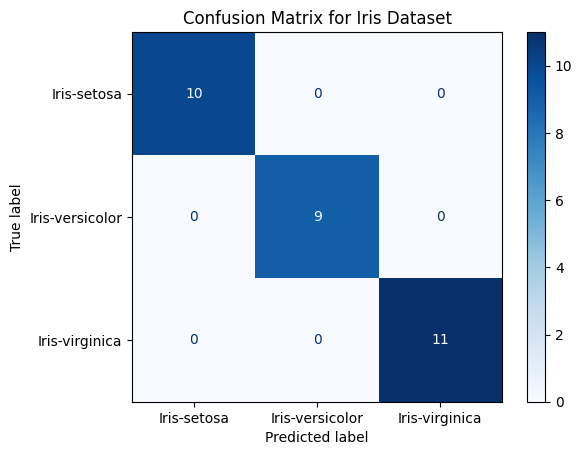

In [ ]:
confusion_matrix_iris = confusion_matrix(y_test_iris, y_pred_iris)

# Get unique class labels from the test set for display labels
class_labels_iris = sorted(y_test_iris.unique())

cm_display_iris = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_iris, display_labels = class_labels_iris)

plt.figure(figsize=(8, 6))
cm_display_iris.plot(cmap='Blues')
plt.title('Confusion Matrix for Iris Dataset')
plt.show()